In this notebook we will cover some of the basic strategies to perform error mitigation for measurement errors.

### Brief introduction

After a projective measurement at the end of the quantum circuit, the experimental outcomes can be thought as being sampled from a density matrix which is diagonal in the computational basis. For two qubits for instance this would look like

$$\rho_{meas} = \mathcal{M}[\rho] = p_{00}\rvert00\rangle\langle00\lvert+p_{01}\rvert01\rangle\langle01\lvert+p_{10}\rvert10\rangle\langle10\lvert+p_{11}\rvert11\rangle\langle11\lvert\equiv\sum_k p_k\rvert k\rangle\langle k\lvert$$

where $\mathcal{M}[\cdot]$ is the measurement channel. The diagonal matrix elements satisfy $\sum_k p_k=1$ (coming from $Tr[\rho]=1$) and we can therefore think of $\rho_{meas}$ as providing a representation of a classical probability distribution over the $2^n$ possible bit-strings. Note that the probabilities $p_k$ are just the diagonal elements $\rho_{kk}$ of the original density matrix describing the quantum state.

A simple but effective model for the errors that can affect the measurement process is to consider the physically implemented measurement channel $\mathcal{M}_{phys}[\cdot]$ as being the composition of the ideal measurement $\mathcal{M}$ with an error channel $\mathcal{E}_M$ that sends probability distributions into probability distributions so that

$$\mathcal{M}_{phys}[\rho]=\mathcal{E}_M\left[\mathcal{M}[\rho]\right]=\sum_k p^{(e)}_k\rvert k\rangle\langle k\lvert$$

A common assumption is that also $\sum_k p_k^{(e)}=1$ (in technical language this means that the channel $\mathcal{E}_M$ is *trace preserving*) and, even if not completely realistic (why?), it oftens works well in practice.

The simplest model for $\mathcal{E}_M$ is a single-qubit bit-flip channel which for a single qubits looks like

$$\mathcal{E}_M[\rho] = (1-p)\rho + pX\rho X$$

while for $n$ qubits this can be generalized by taking tensor products.

An intuitive way to think about the action of this channel is that, for each qubit, we apply a $X$ gate with probability $p$ flipping the associated value. In this way the probability for a single bit-flip to  happen on any of the $n$ qubits is $~p$, the probability that two errors happen is $~p^2$ and so on.

A more realistic model can be obtained by allowing 
- the error probabilities on each qubit to vary
- using different probabilities for a raising error ($\rvert1\rangle\langle0\lvert$) and a lowering error ($\rvert0\rangle\langle1\lvert$) in order to model spontaneus decay processes and thermal excitations
- allowing also for different probabilities on correlated bit-flips (e.g. with two-qubit operators like X_0X_1)

In this picture the noise channel can be described by a stochastic matrix acting on the ideal probability distribution for instance as follows

$$\begin{pmatrix} p^{(e)}_{0}\\p^{(e)}_{1}\end{pmatrix} = \begin{pmatrix}
P(0|0) & P(0|1)\\
P(1|0) & P(1|1)
\end{pmatrix}\begin{pmatrix} p_{0}\\p_{1}\end{pmatrix}$$
where we denoted by $P(a|b)$ the probability of observing the value $a$ when the real value was $b$.

The stochastic matrix defined above takes several names in literature including: confusion matrix, calibration matrix, assignment matrix and many more. Using the fact that for a stochastic matrix the number of independent elements in a column with $N$ elements is only $N-1$ (since they need to sum to 1), a general parametrization for the calibration matrix for a single qubit is then

$$\begin{pmatrix}
P(0|0) & P(0|1)\\
P(1|0) & P(1|1)
\end{pmatrix}=
\begin{pmatrix}
1-e_0 & e_1\\
e_0 & 1-e_1
\end{pmatrix}$$

In order to remove the effect of the error we can solve for the correct probabilities $(p_0,p_1)$ by solving the linear system above as

$$\begin{pmatrix} p_{0}\\p_{1}\end{pmatrix} = \begin{pmatrix}
1-e_0 & e_1\\
e_0 & 1-e_1
\end{pmatrix}^{-1}\begin{pmatrix} p^{(e)}_{0}\\p^{(e)}_{1}\end{pmatrix}$$

In order to deal with systems with more than one qubit we to find a good generalization for this procedure. The most direct approach is that all the error probabilities are independent, for $n=2$ qubits we would then have to deal with a $4\times4$ calibration matrix instead

$$\begin{pmatrix} p_{00e}\\p_{01e}\\p_{10e}\\p_{11e}\end{pmatrix} = \begin{pmatrix}
P(00|00) & P(00|01)&P(00|10) & P(00|11)\\
P(01|00) & P(01|01)&P(01|10) & P(01|11)\\
P(10|00) & P(10|01)&P(10|10) & P(10|11)\\
P(11|00) & P(11|01)&P(11|10) & P(11|11)\\
\end{pmatrix}\begin{pmatrix} p_{00}\\p_{01}\\p_{10}\\p_{11}\end{pmatrix}$$

The code below shows a few example on how to perform this error mitigation in practice.

### Noise simulator setup

In [1]:
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2
# Generate a 5-qubit simulated backend
my_coupling_map = [(0, 2), (1, 2), (2, 3), (2, 4)] ## this is the same coupling map as Lagrange 
fake_lagrange_backend = GenericBackendV2(
    num_qubits=5,
    coupling_map=my_coupling_map,
    basis_gates=["id", "rz", "sx", "x", "cz"],
    seed=42 # set a fixed seed for PRNG
)

We now generate a simple noise model with typical parameters for our fake backend

In [2]:
noise_model = NoiseModel.from_backend(fake_lagrange_backend)

In [3]:
print(noise_model)

NoiseModel:
  Basis gates: ['cz', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'measure', 'cz', 'x', 'sx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('cz', (0, 2)), ('cz', (1, 2)), ('cz', (2, 3)), ('cz', (2, 4)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]


In [4]:
nmodel = NoiseModel.from_backend(fake_lagrange_backend,gate_error=False,thermal_relaxation=False)

Let's now make a simple circuit on two qubits to test the effect of noise

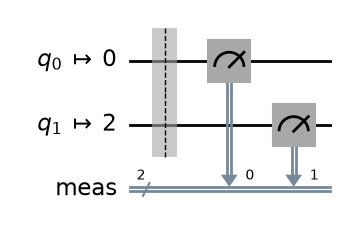

In [5]:
from qiskit import transpile
from qiskit import QuantumCircuit

circuitA = QuantumCircuit(2)
circuitA.measure_all()

# now we transpile it
transpiled_circuitA = transpile(circuitA, 
                                backend=fake_lagrange_backend,
                                optimization_level=0,
                                initial_layout=[0,2]
)
transpiled_circuitA.draw('mpl')

In [6]:
from qiskit_aer import AerSimulator
sim_noisy = AerSimulator(noise_model=nmodel,target=fake_lagrange_backend)

In [7]:
sample_jobA = sim_noisy.run([transpiled_circuitA],shots=4096,seed_simulator=21)
counts_circuitA = sample_jobA.result().get_counts()

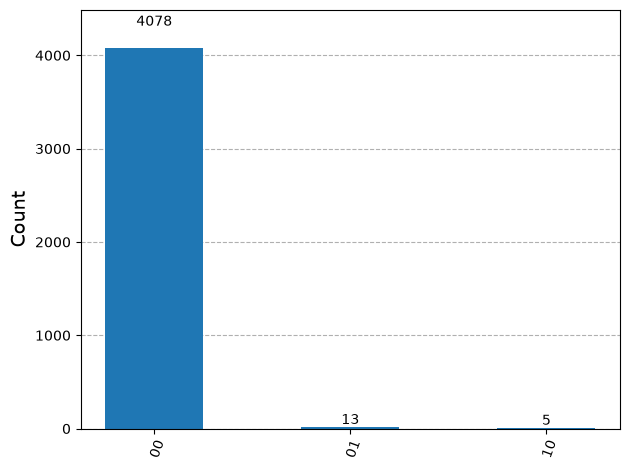

In [8]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_circuitA)

You can see that the probability of having two errors is sufficiently small that the $11$ result never appear.
    
### Estimating calibration matrices

In order to better characterize the noise we can estimate the calibration matrix explicitly. For now we only care about the single qubit calibration matrices which can be measured in parallel for all qubits as follows


In [9]:
cal_circuits_simple = []
## first one for the 00 string
cal_circ_00 = QuantumCircuit(2)
cal_circ_00.measure_all()
cal_circuits_simple.append(cal_circ_00)
## last one for the 11 string
cal_circ_11 = QuantumCircuit(2)
cal_circ_11.x(0)
cal_circ_11.x(1)
cal_circ_11.measure_all()
cal_circuits_simple.append(cal_circ_11)

In [10]:
# transpile them all
transpiled_cal_circuits_simple = []
for circ in cal_circuits_simple:
    traspiled_circ = transpile(circ, 
                               backend=fake_lagrange_backend,
                               optimization_level=0,
                               initial_layout=[0,2]
                        )
    transpiled_cal_circuits_simple.append(traspiled_circ)

In [11]:
## let's use a large number of shots to get good statistics
simple_cal_job = sim_noisy.run(transpiled_cal_circuits_simple,shots=100000,seed_simulator=21)
counts_cal_simple = simple_cal_job.result().get_counts()

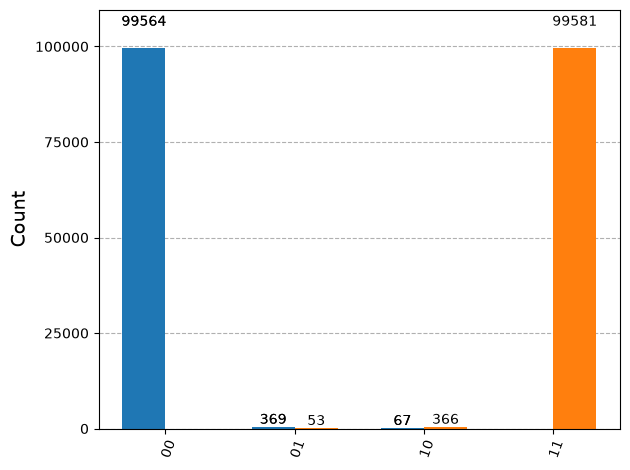

In [12]:
plot_histogram(counts_cal_simple)

In [13]:
# probability of measuring qubit 0 in 0 when starting in 0
## we use the first calibration circuit
tot_counts = sum([counts_cal_simple[0][kk] for kk in counts_cal_simple[0].keys()])
p_00_0 = 0
for cnt in counts_cal_simple[0]:
    print(cnt,cnt[0],cnt[1],cnt[1]=='0')
    if cnt[1]=='0':
        p_00_0 += counts_cal_simple[0][cnt]
    print(f"\t{p_00_0}\t{counts_cal_simple[0][cnt]}")
## now we normalize with all counts
p_00_0 /= tot_counts
# probability of measuring qubit 0 in 1 when starting in 0 is simply
p_01_0 = 1.-p_00_0

01 0 1 False
	0	369
10 1 0 True
	67	67
00 0 0 True
	99631	99564


In [14]:
noise_dict = nmodel.to_dict()
ro_err_0 = noise_dict['errors'][0]
print("RO error on qubit 0:\n",ro_err_0)
ro_err_2 = noise_dict['errors'][2]
print("RO error on qubit 2:\n",ro_err_2)
# we can now compare the empirical calibration with the noise model parameters
p_00_0_theo = ro_err_0['probabilities'][0][0]
p_01_0_theo = ro_err_0['probabilities'][1][0]
print(f"p_00_0: {p_00_0:.4f}\t[theory: {p_00_0_theo:.4f}]")
print(f"p_01_0: {p_01_0:.4f}\t[theory: {p_01_0_theo:.4f}]")

RO error on qubit 0:
 {'type': 'roerror', 'operations': ['measure'], 'probabilities': [[0.9964712247606546, 0.0035287752393454125], [0.0035287752393454125, 0.9964712247606546]], 'gate_qubits': [(0,)]}
RO error on qubit 2:
 {'type': 'roerror', 'operations': ['measure'], 'probabilities': [[0.999292412979343, 0.0007075870206570108], [0.0007075870206570108, 0.999292412979343]], 'gate_qubits': [(2,)]}
p_00_0: 0.9963	[theory: 0.9965]
p_01_0: 0.0037	[theory: 0.0035]


In [15]:
import numpy as np
def get_single_qubit_ro_probs(calibration_counts):
    # extract keys in counts for first circuit
    keys_list0 = [key for key in calibration_counts[0].keys()]
    # get number of qubits in counts
    num_qubits0 = len(keys_list0[0])
    print(f"_Found {num_qubits0} qubits in first calibration circuit counts")
    ## cycle over qubits
    cmatrices = []
    for qq in range(num_qubits0):
        ## we use the first calibration circuit for p00 and p10
        tot_counts0 = sum([calibration_counts[0][kk] for kk in keys_list0])
        p_00 = 0
        for key in keys_list0:
            ## qubits are labelled starting from the right in qiskit
            if key[num_qubits0-1-qq]=='0':
                p_00 += calibration_counts[0][key]
        ## now we normalize with all counts
        p_00 /= tot_counts0
        # probability of measuring qubit 0 in 1 when starting in 0 is simply
        p_01 = 1.-p_00
        ## we now use the second calibration circuit for p11 and p01
        keys_list1 = [key for key in calibration_counts[1].keys()]
        num_qubits1 = len(keys_list0[0])
        if num_qubits0 != num_qubits1:
            raise Exception("Number of qubits in calibration circuits do not match")
        tot_counts1 = sum([calibration_counts[1][kk] for kk in keys_list1])
        p_11 = 0
        for key in keys_list1:
            ## qubits are labelled starting from the right in qiskit
            if key[num_qubits1-1-qq]=='1':
                p_11 += calibration_counts[1][key]
        ## now we normalize with all counts
        p_11 /= tot_counts1
        # probability of measuring qubit 0 in 1 when starting in 0 is simply
        p_10 = 1.-p_11
        ## make confusion matrix for this qubit
        cmatrix = np.array([[p_00,p_10],
                            [p_01,p_11]])
        # add to the list
        cmatrices.append(cmatrix)

    return cmatrices

In [16]:
cal_matrices = get_single_qubit_ro_probs(counts_cal_simple)

_Found 2 qubits in first calibration circuit counts


In [17]:
cal_matrices

[array([[0.99631, 0.00366],
        [0.00369, 0.99634]]),
 array([[9.9933e-01, 5.3000e-04],
        [6.7000e-04, 9.9947e-01]])]

## Example 1

Let's try to test this on a simple problem. We aim to measure the expectation values $\langle X_0\rangle$, $\langle X_1\rangle$,$\langle Z_0\rangle$ and $\langle Z_1\rangle$ on the following state

$$\rvert\Psi(\theta)\rangle = \cos(\theta)\rvert 01\rangle+\sin(\theta)\rvert10\rangle$$

We start computing the expected exact values (here with numpy but you could've used a state-vector simulation instead)

In [18]:
# let's code the ideal circuit in numpy first
import numpy as np

# we start defining all the Pauli observables
I = np.eye(2)
X = np.array([[0,1],[1,0]],dtype=complex)
Y = np.array([[0,-1.j],[1.j,0]],dtype=complex)
Z = np.array([[1,0],[0,-1]],dtype=complex)
# and now all possible two qubit observables
## NOTE: qiskit uses an ordering that goes left to right, we will do the same here
X_1 = np.kron(X,I); Y_1 = np.kron(Y,I); Z_1 = np.kron(Z,I)
X_0 = np.kron(I,X); Y_0 = np.kron(I,Y); Z_0 = np.kron(I,Z)
X_0X_1 = np.kron(X,X); Y_0X_1 = np.kron(X,Y); Z_0X_1 = np.kron(X,Z)
X_0Y_1 = np.kron(Y,X); Y_0Y_1 = np.kron(Y,Y); Z_0Y_1 = np.kron(Y,Z)
X_0Z_1 = np.kron(Z,X); Y_0Z_1 = np.kron(Z,Y); Z_0Z_1 = np.kron(Z,Z)

# these are the computational states
zero_state=np.array([1,0])
one_state=np.array([0,1])
theta=0.5
# note the ordering convention to comply with the one in qiskit
state_00 = np.kron(zero_state,zero_state)
state_11 = np.kron(one_state,one_state)
# this is our target state
psi_theta = np.cos(theta)*state_00+np.sin(theta)*state_11
print(f"<X_0>: {np.vdot(psi_theta,X_0@psi_theta)}\t<X_1>: {np.vdot(psi_theta,X_1@psi_theta)}")
print(f"<Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}\t<Z_1>: {np.vdot(psi_theta,Z_1@psi_theta)}")

<X_0>: 0j	<X_1>: 0j
<Z_0>: (0.5403023058681398+0j)	<Z_1>: (0.5403023058681398+0j)


In [19]:
circuit_calc = QuantumCircuit(2)
## note the factor of 2 needed to comply with qiskit conventions
circuit_calc.ry(2*theta,0)
#circuit_calc.x(1)
circuit_calc.cx(0, 1)
## we now make one circuit for Z measurements and one for X measurements
circuit_meas_X = circuit_calc.copy()
circuit_meas_X.h([0,1])
circuit_meas_X.measure_all()
circuit_meas_Z = circuit_calc.copy()
circuit_meas_Z.measure_all()
## we can now prepare the calibration circuits
cal_circuits_simple = []
## first one for the 00 string
cal_circ_00 = QuantumCircuit(2)
cal_circ_00.measure_all()
cal_circuits_simple.append(cal_circ_00)
## last one for the 11 string
cal_circ_11 = QuantumCircuit(2)
cal_circ_11.x(0)
cal_circ_11.x(1)
cal_circ_11.measure_all()
cal_circuits_simple.append(cal_circ_11)

We are now ready to prepare the job. We first collect all circuits we need in one list

In [20]:
job_circuits = []
## calibration first
for c in cal_circuits_simple:
    job_circuits.append(c)
## measurement circuits now
job_circuits.append(circuit_meas_X)
job_circuits.append(circuit_meas_Z)
## we are now ready for transpiling them all
# transpile them all
transpiled_job_circuits = []
for circ in job_circuits:
    traspiled_circ = transpile(circ, 
                               backend=fake_lagrange_backend,
                               optimization_level=0,
                               initial_layout=[0,2]
                        )
    transpiled_job_circuits.append(traspiled_circ)

In [21]:
## we run and collect counts
job = sim_noisy.run(transpiled_job_circuits,shots=100000,seed_simulator=21)
counts = job.result().get_counts()

Let's first estimate the expectation values of $X$ and $Z$ on both qubits with errors using the routine from the exercise notebook


In [22]:
def prob_and_err_from_counts(input_counts, bits_for_observable):
    tot_counts = sum([input_counts[kk] for kk in input_counts.keys()])
    pi_shots = 0.0
    for cc in input_counts:
        num_qubits = len(cc)
        bit_values = np.array([int(cc[num_qubits-1-bit]) for bit in bits_for_observable])
        pi_shots += input_counts[cc]*np.all(bit_values==np.array([0]*len(bits_for_observable)))

    prob = pi_shots/tot_counts
    prob_err = np.sqrt(prob*(1.-prob)/tot_counts)
    return prob, prob_err

In [23]:
## X_0 first [this is the 3rd circuit]
bits_for_X0 = [0]
p_0, p_0_err = prob_and_err_from_counts(counts[2],bits_for_X0)
## transform probabilities into Pauli expectation values
x_0 = 2*p_0-1.
x_0_err = 2.*p_0_err
print(f"[ERROR] <X_0>: {x_0} +- {x_0_err}")
print(f"[EXACT] <X_0>: {np.vdot(psi_theta,X_0@psi_theta)}")

[ERROR] <X_0>: -0.0021799999999999597 +- 0.0031622701459552757
[EXACT] <X_0>: 0j


In [24]:
## now X_1 [this is the 3rd circuit]
bits_for_X1 = [1]
p_1, p_1_err = prob_and_err_from_counts(counts[2],bits_for_X1)
## transform probabilities into Pauli expectation values
x_1 = 2*p_1-1.
x_1_err = 2.*p_1_err
print(f"[ERROR] <X_1>: {x_1} +- {x_1_err}")
print(f"[EXACT] <X_1>: {np.vdot(psi_theta,X_1@psi_theta)}")
## now Z_0 [this is the 4th circuit]
bits_for_Z0 = [0]
p_0, p_0_err = prob_and_err_from_counts(counts[3],bits_for_Z0)
## transform probabilities into Pauli expectation values
z_0 = 2*p_0-1.
z_0_err = 2.*p_0_err
print(f"[ERROR] <Z_0>: {z_0} +- {z_0_err}")
print(f"[EXACT] <Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}")
## now Z_1 [this is the 4th circuit]
bits_for_Z1 = [1]
p_1, p_1_err = prob_and_err_from_counts(counts[3],bits_for_Z1)
## transform probabilities into Pauli expectation values
z_1 = 2*p_1-1.
z_1_err = 2.*p_1_err
print(f"[ERROR] <Z_1>: {z_1} +- {z_1_err}")
print(f"[EXACT] <Z_1>: {np.vdot(psi_theta,Z_1@psi_theta)}")

[ERROR] <X_1>: -0.0017599999999999838 +- 0.0031622727624289466
[EXACT] <X_1>: 0j
[ERROR] <Z_0>: 0.53538 +- 0.002670895459579053
[EXACT] <Z_0>: (0.5403023058681398+0j)
[ERROR] <Z_1>: 0.53836 +- 0.002664898704266262
[EXACT] <Z_1>: (0.5403023058681398+0j)


And we see that for $Z_0$ we have a definite bias in our estimate. In order to mitigate readout errors we now first extract the calibration matrices

In [25]:
cal_matrices = get_single_qubit_ro_probs(counts_cal_simple)

_Found 2 qubits in first calibration circuit counts


In [26]:
## X_0 first [this is the 3rd circuit]
bits_for_X0 = [0]
p_0, p_0_err = prob_and_err_from_counts(counts[2],bits_for_X0)
perr = np.array([p_0,1.-p_0])
pmit = np.linalg.inv(cal_matrices[0])@perr
x_0 = 2*perr[0]-1.
x_0_err = 2.*p_0_err
print(f"[ERROR] <X_0>: {x_0} +- {x_0_err}")
x_0 = 2*pmit[0]-1.
x_0_err = 2.*p_0_err ## how good is this??
print(f"[MITIG] <X_0>: {x_0} +- {x_0_err}")
print(f"[EXACT] <X_0>: {np.vdot(psi_theta,X_0@psi_theta)}")

[ERROR] <X_0>: -0.0021799999999999597 +- 0.0031622701459552757
[MITIG] <X_0>: -0.0021659195083866267 +- 0.0031622701459552757
[EXACT] <X_0>: 0j


In [27]:
## now Z_0 [this is the 4th circuit]
bits_for_Z0 = [0]
p_0, p_0_err = prob_and_err_from_counts(counts[3],bits_for_Z0)
## transform probabilities into Pauli expectation values
z_0 = 2*p_0-1.
z_0_err = 2.*p_0_err
print(f"[ERROR] <Z_0>: {z_0} +- {z_0_err}")
perr = np.array([p_0,1.-p_0])
pmit = np.linalg.inv(cal_matrices[0])@perr
z_0 = 2*pmit[0]-1.
z_0_err = 2.*p_0_err ## how good is this??
print(f"[MITIG] <Z_0>: {z_0} +- {z_0_err}")
print(f"[EXACT] <Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}")

[ERROR] <Z_0>: 0.53538 +- 0.002670895459579053
[MITIG] <Z_0>: 0.5393744018536242 +- 0.002670895459579053
[EXACT] <Z_0>: (0.5403023058681398+0j)


### Multi qubit observables 

In a multi-qubit system, whenever we are interested in more than just single qubit observables, we would in principle need to estimate the full calibration matrix with $2^n\times2^n$ entries (how many circuits would this estimation require?) which becomes quickly intractable for large systems. A commonly used model, which is not very realistic but still performs reasonably well on some platforms, is to assume that errors on different qubits are completely independent so that we can build the full calibration matrix from tensor products of single qubit ones. For $n=2$ for instance this would look like

$$\begin{pmatrix}
P(00|00) & P(00|01)&P(00|10) & P(00|11)\\
P(01|00) & P(01|01)&P(01|10) & P(01|11)\\
P(10|00) & P(10|01)&P(10|10) & P(10|11)\\
P(11|00) & P(11|01)&P(11|10) & P(11|11)\\
\end{pmatrix}\approx \begin{pmatrix}
P_1(0|0) & P_1(0|1)\\
P_1(1|0) & P_1(1|1)
\end{pmatrix}\otimes\begin{pmatrix}
P_0(0|0) & P_0(0|1)\\
P_0(1|0) & P_0(1|1)
\end{pmatrix}$$

For this exercises we will only consider this approximation.

### Practical considerations
An easier way to deal with applying the read out mitigation is to apply a correction directly to the bare counts and keep the rest of the code to estimate observables the same. A simple, but inefficient for large systems, way is to apply the correction one qubit at a time, one bit-string at a time. We will apply the correction for the first qubit directly to the raw counts, when we pass to the next qubit we will use instead the mitigated counts at the previous round as the new 'raw_counts'.


In [28]:
def get_mit_counts(raw_counts, num_qubits,cal_matrices):
    ## since we are applying this iteratively we need to update the 'raw_counts' as we go
    raw_counts_now = raw_counts
    # cycle over qubits
    for qnow in range(num_qubits):
        ## start a fresh mitigated counts every cycle
        mit_counts = {}
        # retrieve correct calibration matrix
        cal_mat_now = cal_matrices[qnow]
        # compute inverse
        inv_cal_now = np.linalg.inv(cal_mat_now)
        # cycle over counts
        for cc in raw_counts_now:
            # check if current qubit is set
            if cc[num_qubits-1-qnow]=='0':
                raw_vec = np.array([1,0])
            else:
                raw_vec = np.array([0,1])
            # produce corrected vector
            mit_vec = inv_cal_now@raw_vec
            # assign new mitigated counts
            ## start with 0
            lcc = list(cc)
            lcc[num_qubits-1-qnow]='0'
            newcc = ''.join(lcc)
            ## check if present
            if newcc in mit_counts:
                ## then we add
                mit_counts[newcc] += raw_counts_now[cc]*mit_vec[0]
            else:
                ## we make new one
                mit_counts[newcc] = raw_counts_now[cc]*mit_vec[0]
            ## then we do 1
            lcc[num_qubits-1-qnow]='1'
            newcc = ''.join(lcc)
            ## check if present
            if newcc in mit_counts:
                ## then we add
                mit_counts[newcc] += raw_counts_now[cc]*mit_vec[1]
            else:
                ## we make new one
                mit_counts[newcc] = raw_counts_now[cc]*mit_vec[1]
        raw_counts_now = mit_counts
    return mit_counts        

In [29]:
raw_counts = counts
raw_counts

[{'01': 369, '10': 67, '00': 99564},
 {'01': 53, '10': 366, '11': 99581},
 {'01': 4129, '11': 45980, '10': 4108, '00': 45783},
 {'01': 277, '11': 22954, '10': 128, '00': 76641}]

In [30]:
num_qubits = 2
mit_counts = []
for rc in raw_counts:
    mc = get_mit_counts(rc,num_qubits,cal_matrices)
    mit_counts.append(mc)
mit_counts

[{'00': np.float64(99999.75064017283),
  '10': np.float64(0.24935982717376248),
  '01': np.float64(0.24935982717146868),
  '11': np.float64(-0.24935982716861602)},
 {'00': np.float64(-0.19565109118702476),
  '10': np.float64(0.19565109118736637),
  '01': np.float64(0.19565109118396862),
  '11': np.float64(99999.80434890882)},
 {'00': np.float64(45966.683548188106),
  '10': np.float64(3925.020476392557),
  '01': np.float64(3952.2191350317503),
  '11': np.float64(46156.07684038759)},
 {'00': np.float64(76976.45629901199),
  '10': np.float64(-7.736206330784356),
  '01': np.float64(-19.10748042969503),
  '11': np.float64(23050.387387748495)}]

The two calibration runs, after mitigation, are now essentially perfect.

Notice however how we now produced negative 'counts'? This comes from statistical uncertainties in the calibration matrix that can propagate to the mitigated results. As you can see the contribution is minor in this case but it stresses the fact we need to find a good procedure to account for these errors in the final results.

Often these negative counts do not create too many problems but they become important if we want to estimate individual probabilities and their associated statistical errors. There are many, more or less ad-hoc, strategies to avoid this problem. A clean way for instance would be to find the positive definite probability vector that best approximates the solution of the linear system with a given calibration matrix and observed noisy probabilities.

A more ad-hoc way that works reasonably well is to instead spread the negative counts over the remaining bit strings until we obtain a valid probability distribution.

The following is a simple implementation of this idea where we recoursively start from the bit-strings with the largest negative counts and spread the resulting negative count evenly among the remaining bit-strings until all counts are positive definite. This strategy ensures that the normalization is preserved in the process.

In [31]:
def fix_negative(in_counts,verbose=False):
    counts_now = in_counts.copy()
    # extract keys into list
    key_list = []
    for kk in counts_now:
        key_list.append(kk)
    num_strings = len(key_list)
    # make ordered array for counts
    count_array  = np.zeros(num_strings)
    for idx in range(num_strings):
        count_array[idx] = counts_now[key_list[idx]]
    sorted_array = np.sort(count_array)
    # and matching one for keys
    sorted_key_list = [key_list[kk] for kk in np.argsort(count_array)]
    # now go from smallest negative value and push weigth forward untill no more negative counts
    for idx in range(num_strings):
        if verbose:
            print(idx,sorted_array)
        if sorted_array[idx]<0:
            remaining_strings = num_strings-1-idx
            sorted_array[idx+1:] += sorted_array[idx]/remaining_strings
            sorted_array[idx] = 0.0
        else:
            ## if we finished all negative ones we can exit
            break
    # fix counts
    for idx in range(num_strings):
        counts_now[sorted_key_list[idx]] = sorted_array[idx]
    # and return it
    return counts_now

Using mitigated counts we can now estimate the mitigated expectation values in a straightforward way. For instance as follows

In [32]:
## now Z_0 [this is the 4th circuit]
bits_for_Z0 = [0]
p_0_raw, p_0_err_raw = prob_and_err_from_counts(raw_counts[3],bits_for_Z0)
## transform probabilities into Pauli expectation values
z_0_raw = 2*p_0_raw-1.
z_0_err_raw = 2.*p_0_err_raw
print(f"[ERROR] <Z_0>: {z_0_raw} +- {z_0_err_raw}")
### first without correction for negative values
p_0_mit, p_0_err_mit = prob_and_err_from_counts(mit_counts[3],bits_for_Z0)
## transform probabilities into Pauli expectation values
z_0_mit = 2*p_0_mit-1.
z_0_err_mit = 2.*p_0_err_mit
print(f"[MITIG] <Z_0>: {z_0_mit} +- {z_0_err_mit}")
### now with correction for negative values
p_0_mit, p_0_err_mit = prob_and_err_from_counts(fix_negative(mit_counts[3]),bits_for_Z0)
## transform probabilities into Pauli expectation values
z_0_mit = 2*p_0_mit-1.
z_0_err_mit = 2.*p_0_err_mit
print(f"[MITIG-S] <Z_0>: {z_0_mit} +- {z_0_err_mit}")
print(f"[EXACT] <Z_0>: {np.vdot(psi_theta,Z_0@psi_theta)}")

[ERROR] <Z_0>: 0.53538 +- 0.002670895459579053
[MITIG] <Z_0>: 0.5393744018536242 +- 0.0026628466997276525
[MITIG-S] <Z_0>: 0.5392606891126348 +- 0.0026630769969675423
[EXACT] <Z_0>: (0.5403023058681398+0j)


Now our estimate of the statistical error for the mitigated version has been affected by the process. This of course does not capture the statistical uncertainty produced by our finite sample estimator of the calibration matrix.

- **BONUS EXERCISE**: How would you account for these additional contributions to the final error?